# Stress Prediction

Using 60-sec windows of signal data, predict the label of the signal between the categories of baseline, stress, amusement and meditation.

We want to experiment in using limited or simple techniques, but involve some of the metadata which was not taken into consideration in the original paper we studied to add features and possibly help inform the model further.

We will be analysing 2 base models, RandomForest as a baseline ensemble model which is used pretty much universally as a good baseline for model creation, and a more complicated model XGBoost.

Possibility of adding a pytorch transformer model 

## Steps completed

- eda (done in signals.ipynb)
- feature extraction (done in signals.ipynb)

## Steps to complete

- train/test split
- feature selection
- model training
- model evaluation and comparison
- model explanations using SHAP

## NOTE

This notebook contains a strange version of the problem, because we decided to see how far we could push models using additional features (see: the metadata), but without using temporal features instead. 
This is not very accurate, but we hoped the experiment would be informative.

It should be noted that the models here do not boast extraordinary performance...

In [1]:
# Imports

# Math
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import itertools

# Visualisations
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, f1_score, accuracy_score, precision_recall_fscore_support, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import shap


I0000 00:00:1778450020.923118 1221850 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778450020.924332 1221850 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778450021.146617 1221850 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778450022.273719 1221850 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

### Data
We will be using the wrist sensor data with metadata attached, hopefully giving us further insights which were not used in the original paper we studied.

It should also be noted that we decided to remove the temporal feature, `window_index`, and instead try classifying the 60-second segments based only on the physiological data available through the wrist device.
For this reason, we have to remove the column right after loading the data, before performing anything interesting.

At the same time as removing that feature column, we are also going to be changing the values in the target column (`label`) as one of our chosen model architectures (XGBoost) requires the values to start from 0, and changing the "subject" data from type string (see: "S10") to type int (see: "10").

In [2]:
# Import data
data_folder = "data/"

data = pd.read_csv(data_folder + "wesad_wrist_features.csv")
data_with_metadata = pd.read_csv(data_folder + "merged_metadata_wrist_features.csv")
data_all = pd.read_csv(data_folder + "merged_survey_metadata_wrist_features.csv")

target_dict = {0: "Baseline", 1: "Stress", 2: "Amusement", 3: "Meditation"}

# # not using this one
# print("Wrist device data, as preprocessed in 'signals.ipynb':")
# display(data.head())
# print(f"Features: {data.shape[1]} total\n{data.columns}")

print()
print("Data with metadata, as preprocessed in 'signals.ipynb' and merged with metadata in 'metadata.ipynb':")
display(data_with_metadata.head())
print(f"Features: {data_with_metadata.shape[1]} total\n\t{data_with_metadata.columns}")

# # Ended up not using this one (sorry Louie)
# print()
# print("Data with metadata and survey questions, preprocessed in 'signals.ipynb' and 'metadata.ipynb':")
# display(data_all.head())
# print(f"Features: {data_all.shape[1]} total\n\t{data_all.columns}")




Data with metadata, as preprocessed in 'signals.ipynb' and merged with metadata in 'metadata.ipynb':


,subject,age,height,weight,bmi,gender_male,coffee_today_YES,sports_today_YES,smoker_YES,ill_today_YES,...,acc_mag_mean,acc_mag_std,acc_x_absint,acc_y_absint,acc_z_absint,acc_x_peakfreq,acc_y_peakfreq,acc_z_peakfreq,eda_scr_has_peaks,bvp_hrv_freq_valid
0,S10,28,178,76,24.0,1,0,0,0,0,...,61.879907,3.012126,2384.783203,202.807617,2570.923828,0.125,0.125,0.125,1,1
1,S10,28,178,76,24.0,1,0,0,0,0,...,61.877399,3.008428,2377.814453,201.671875,2578.465820,0.125,0.125,0.125,1,1
2,S10,28,178,76,24.0,1,0,0,0,0,...,61.873905,3.010429,2370.814453,200.614258,2585.978516,0.125,0.125,0.125,1,1
3,S10,28,178,76,24.0,1,0,0,0,0,...,61.870738,3.011397,2363.833008,199.660156,2593.484375,0.125,0.125,0.125,1,1
4,S10,28,178,76,24.0,1,0,0,0,0,...,61.868780,3.009604,2356.885742,198.826172,2601.025391,0.125,0.125,0.125,1,1


Features: 55 total
	Index(['subject', 'age', 'height', 'weight', 'bmi', 'gender_male',
       'coffee_today_YES', 'sports_today_YES', 'smoker_YES', 'ill_today_YES',
       'window_index', 'label', 'bvp_hr_mean', 'bvp_hr_std', 'bvp_hrv_mean',
       'bvp_hrv_std', 'bvp_hrv_nn50', 'bvp_hrv_pnn50', 'bvp_hrv_rmssd',
       'bvp_hrv_ulf', 'bvp_hrv_lf', 'bvp_hrv_hf', 'bvp_hrv_uhf',
       'bvp_hrv_lf_hf', 'eda_mean', 'eda_std', 'eda_min', 'eda_max',
       'eda_slope', 'eda_range', 'eda_scr_peaks', 'eda_scr_mean_amp',
       'eda_scr_auc', 'temp_mean', 'temp_std', 'temp_min', 'temp_max',
       'temp_range', 'temp_slope', 'acc_x_mean', 'acc_x_std', 'acc_y_mean',
       'acc_y_std', 'acc_z_mean', 'acc_z_std', 'acc_mag_mean', 'acc_mag_std',
       'acc_x_absint', 'acc_y_absint', 'acc_z_absint', 'acc_x_peakfreq',
       'acc_y_peakfreq', 'acc_z_peakfreq', 'eda_scr_has_peaks',
       'bvp_hrv_freq_valid'],
      dtype='str')


In [3]:
# removing window index because its like giving 
data_with_metadata.drop("window_index", axis=1, inplace=True)
data_with_metadata["label"] = data_with_metadata["label"].apply(lambda x: x-1)
data_with_metadata["subject"] = data_with_metadata["subject"].apply(lambda x: int(x[1:]))

data_with_metadata.head()

,subject,age,height,weight,bmi,gender_male,coffee_today_YES,sports_today_YES,smoker_YES,ill_today_YES,...,acc_mag_mean,acc_mag_std,acc_x_absint,acc_y_absint,acc_z_absint,acc_x_peakfreq,acc_y_peakfreq,acc_z_peakfreq,eda_scr_has_peaks,bvp_hrv_freq_valid
0,10,28,178,76,24.0,1,0,0,0,0,...,61.879907,3.012126,2384.783203,202.807617,2570.923828,0.125,0.125,0.125,1,1
1,10,28,178,76,24.0,1,0,0,0,0,...,61.877399,3.008428,2377.814453,201.671875,2578.465820,0.125,0.125,0.125,1,1
2,10,28,178,76,24.0,1,0,0,0,0,...,61.873905,3.010429,2370.814453,200.614258,2585.978516,0.125,0.125,0.125,1,1
3,10,28,178,76,24.0,1,0,0,0,0,...,61.870738,3.011397,2363.833008,199.660156,2593.484375,0.125,0.125,0.125,1,1
4,10,28,178,76,24.0,1,0,0,0,0,...,61.868780,3.009604,2356.885742,198.826172,2601.025391,0.125,0.125,0.125,1,1


### Splitting the data

We need to make sure, for data leakage reasoning and also for generalisability and real world simulation, that no subjects that are present in the training set are also present in the test set.
For this reason, instead of performing a random split of the data for training and testing purposes, we will instead separate the subjects into the train, validation and test splits, then take all data relative to each subject and use that for the splits.

This might cause some strange inconsistencies in our case as we have so few subjects (15 after preprocessing), but it is nonetheless the correct way of moving forwards with this problem, and some issues that we encounter could be fixed in the future with data collection.

In [4]:
# train/test split
# we need all subjects to be in the same split

subjects = list(data_with_metadata.subject.unique())
n_subjects = len(subjects)
print(f"Subjects: {subjects}")
print(f"Number of subjects: {n_subjects}")

train_ratio, test_ratio, val_ratio = 0.7, 0.2, 0.1
# print(train_ratio + test_ratio + val_ratio) # why doesnt it just print 1 :|

n_train, n_test, n_val = round(n_subjects * train_ratio), round(n_subjects * test_ratio), round(n_subjects * val_ratio)
print(f"\tIn train set: {n_train}\n\tIn validation set: {n_val}\n\tIn test set: {n_test}")
print(f"Sum, to make sure total is unchanged: {n_train + n_test + n_val}")



Subjects: [np.int64(10), np.int64(11), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Number of subjects: 15
	In train set: 10
	In validation set: 2
	In test set: 3
Sum, to make sure total is unchanged: 15


In [5]:
# Assign subjects to different sets
subjects_copy = subjects.copy()

train_subjects = []
for i in range(n_train):
    train_subjects.append(subjects_copy.pop(np.random.randint(len(subjects_copy))))

test_subjects = []
for i in range(n_test):
    test_subjects.append(subjects_copy.pop(np.random.randint(len(subjects_copy))))

val_subjects = subjects_copy.copy()

train_subjects, test_subjects, val_subjects = sorted(train_subjects), sorted(test_subjects), sorted(val_subjects)

print(f"Subjects per set:\n\ttrain: {train_subjects}\n\tvalidation: {val_subjects}\n\ttest: {test_subjects}")

Subjects per set:
	train: [np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(13), np.int64(15), np.int64(16)]
	validation: [np.int64(3), np.int64(11)]
	test: [np.int64(8), np.int64(14), np.int64(17)]


In [6]:
# for reproducibility, instead of randomly assigning use:

train_subjects = [2, 4, 6, 7, 8, 9, 10, 14, 15, 16] # ['S8', 'S11', 'S4', 'S2', 'S10', 'S14', 'S5', 'S6', 'S7', 'S9']
val_subjects = [3, 13] # ['S15', 'S3']
test_subjects = [5, 11, 17] # ['S13', 'S16', 'S17']

In [7]:
# Select the appropriate subjects for each split
X_train = data_with_metadata.loc[data_with_metadata["subject"].isin(train_subjects)].copy()
X_val = data_with_metadata.loc[data_with_metadata["subject"].isin(val_subjects)].copy()
X_test = data_with_metadata.loc[data_with_metadata["subject"].isin(test_subjects)].copy()

# reindexing at same time for ease of use later
X_train.reindex()


X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

X_val.index = range(len(X_train), len(X_train) + len(X_val))
X_test.index = range(len(X_train) + len(X_val), len(X_train) + len(X_val) + len(X_test))

# set the label as the target
y_train = X_train["label"]
y_val = X_val["label"]
y_test = X_test["label"]

# remove the target from input data
X_train.drop("label", axis=1, inplace=True)
X_val.drop("label", axis=1, inplace=True)
X_test.drop("label", axis=1, inplace=True)

display(X_train.head(), y_train.head(), X_val.head(), y_val.head(), X_test.head(), y_test.head())


,subject,age,height,weight,bmi,gender_male,coffee_today_YES,sports_today_YES,smoker_YES,ill_today_YES,...,acc_mag_mean,acc_mag_std,acc_x_absint,acc_y_absint,acc_z_absint,acc_x_peakfreq,acc_y_peakfreq,acc_z_peakfreq,eda_scr_has_peaks,bvp_hrv_freq_valid
0,10,28,178,76,24.0,1,0,0,0,0,...,61.879907,3.012126,2384.783203,202.807617,2570.923828,0.125,0.125,0.125,1,1
1,10,28,178,76,24.0,1,0,0,0,0,...,61.877399,3.008428,2377.814453,201.671875,2578.465820,0.125,0.125,0.125,1,1
2,10,28,178,76,24.0,1,0,0,0,0,...,61.873905,3.010429,2370.814453,200.614258,2585.978516,0.125,0.125,0.125,1,1
3,10,28,178,76,24.0,1,0,0,0,0,...,61.870738,3.011397,2363.833008,199.660156,2593.484375,0.125,0.125,0.125,1,1
4,10,28,178,76,24.0,1,0,0,0,0,...,61.868780,3.009604,2356.885742,198.826172,2601.025391,0.125,0.125,0.125,1,1


0    0
1    0
2    0
3    0
4    0
Name: label, dtype: int64

,subject,age,height,weight,bmi,gender_male,coffee_today_YES,sports_today_YES,smoker_YES,ill_today_YES,...,acc_mag_mean,acc_mag_std,acc_x_absint,acc_y_absint,acc_z_absint,acc_x_peakfreq,acc_y_peakfreq,acc_z_peakfreq,eda_scr_has_peaks,bvp_hrv_freq_valid
119845,13,28,181,82,25.0,1,0,0,0,0,...,61.326299,3.464301,2479.320312,958.505859,1973.221680,0.125,0.125,0.125,1,1
119846,13,28,181,82,25.0,1,0,0,0,0,...,61.324282,3.474617,2481.906250,952.302734,1973.271484,0.125,0.125,0.125,1,1
119847,13,28,181,82,25.0,1,0,0,0,0,...,61.324635,3.471100,2484.677734,946.055664,1973.558594,0.125,0.125,0.125,1,1
119848,13,28,181,82,25.0,1,0,0,0,0,...,61.323710,3.482850,2487.603516,939.467773,1974.034180,0.125,0.125,0.125,1,1
119849,13,28,181,82,25.0,1,0,0,0,0,...,61.327096,3.470826,2490.344727,933.534180,1975.072266,0.125,0.125,0.125,1,1


119845    0
119846    0
119847    0
119848    0
119849    0
Name: label, dtype: int64

,subject,age,height,weight,bmi,gender_male,coffee_today_YES,sports_today_YES,smoker_YES,ill_today_YES,...,acc_mag_mean,acc_mag_std,acc_x_absint,acc_y_absint,acc_z_absint,acc_x_peakfreq,acc_y_peakfreq,acc_z_peakfreq,eda_scr_has_peaks,bvp_hrv_freq_valid
143669,11,26,171,54,18.5,0,1,0,0,0,...,63.166680,4.008690,3156.370117,1133.529297,1589.057617,0.125,0.125,0.125,1,1
143670,11,26,171,54,18.5,0,1,0,0,0,...,63.176281,4.045256,3156.158203,1133.750977,1590.811523,0.125,0.125,0.125,1,1
143671,11,26,171,54,18.5,0,1,0,0,0,...,63.184405,4.092956,3154.885742,1134.917969,1595.367188,0.125,0.125,0.125,1,1
143672,11,26,171,54,18.5,0,1,0,0,0,...,63.215712,4.055792,3155.773438,1135.969727,1597.408203,0.125,0.125,0.125,1,1
143673,11,26,171,54,18.5,0,1,0,0,0,...,63.243801,4.020809,3154.164062,1137.780273,1603.998047,0.125,0.125,0.125,1,1


143669    0
143670    0
143671    0
143672    0
143673    0
Name: label, dtype: int64

We will quickly check the distribution because even though the subjects each have similar amounts of collected wrist device data, there might be additive differences in the sizes.

Text(0.5, 1.0, 'Division of data in splits')

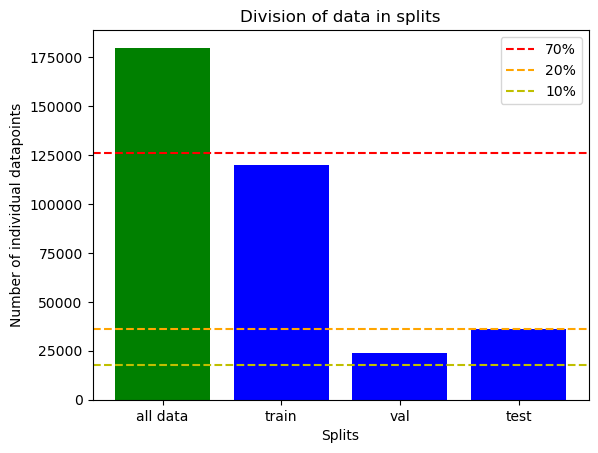

In [8]:
all_data = len(data_with_metadata)
plt.bar(["all data", "train", "val", "test"],
        [all_data, len(X_train), len(X_val), len(X_test)], color=["g", "b", "b", "b"])
plt.ylabel("Number of individual datapoints")
plt.xlabel("Splits")
plt.axhline(0.7 * all_data, linestyle="--", c="r", label="70%")
plt.axhline(0.2 * all_data, linestyle="--", c="orange", label="20%")
plt.axhline(0.1 * all_data, linestyle="--", c="y", label="10%")
plt.legend()
plt.title("Division of data in splits")

It might be also useful to view the distribution of the data post split, at least the training data (and validation set) which is the section we can make decisions based off of in a real life application.
  

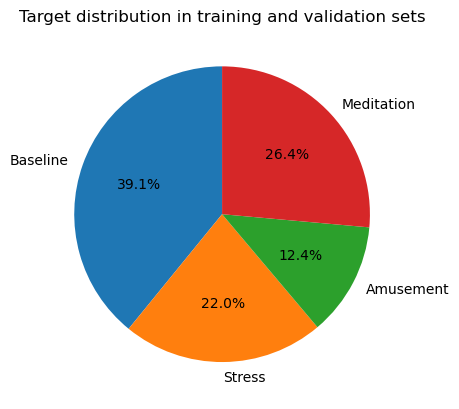

In [9]:
# target distribution in training and validation sets
known_data = pd.concat([X_train, X_val])
known_targets = pd.concat([y_train, y_val])

sorted(list(known_targets))
value_counts = known_targets.value_counts().sort_index()

plt.pie(
    value_counts,
    labels=target_dict.values(),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Target distribution in training and validation sets")
plt.show()


### Normalisation
To check whether to perform scaling or log-normalisation, we need to check if there are many outliers in the training data. 
In the case of skewed columns, log-normalisation can help and doesn't need to be trained beforehand on known data.
In the case of continuous features, scaling is necessary for non-tree-based models, so unnecessary for Random Forest and XGBoost, but is absolutely necessary for those like MLP models.

To make sure we fit all necessary steps, we will log-normalise all skewed features, and scale all the features in a separate dataframe to be used by MLP.

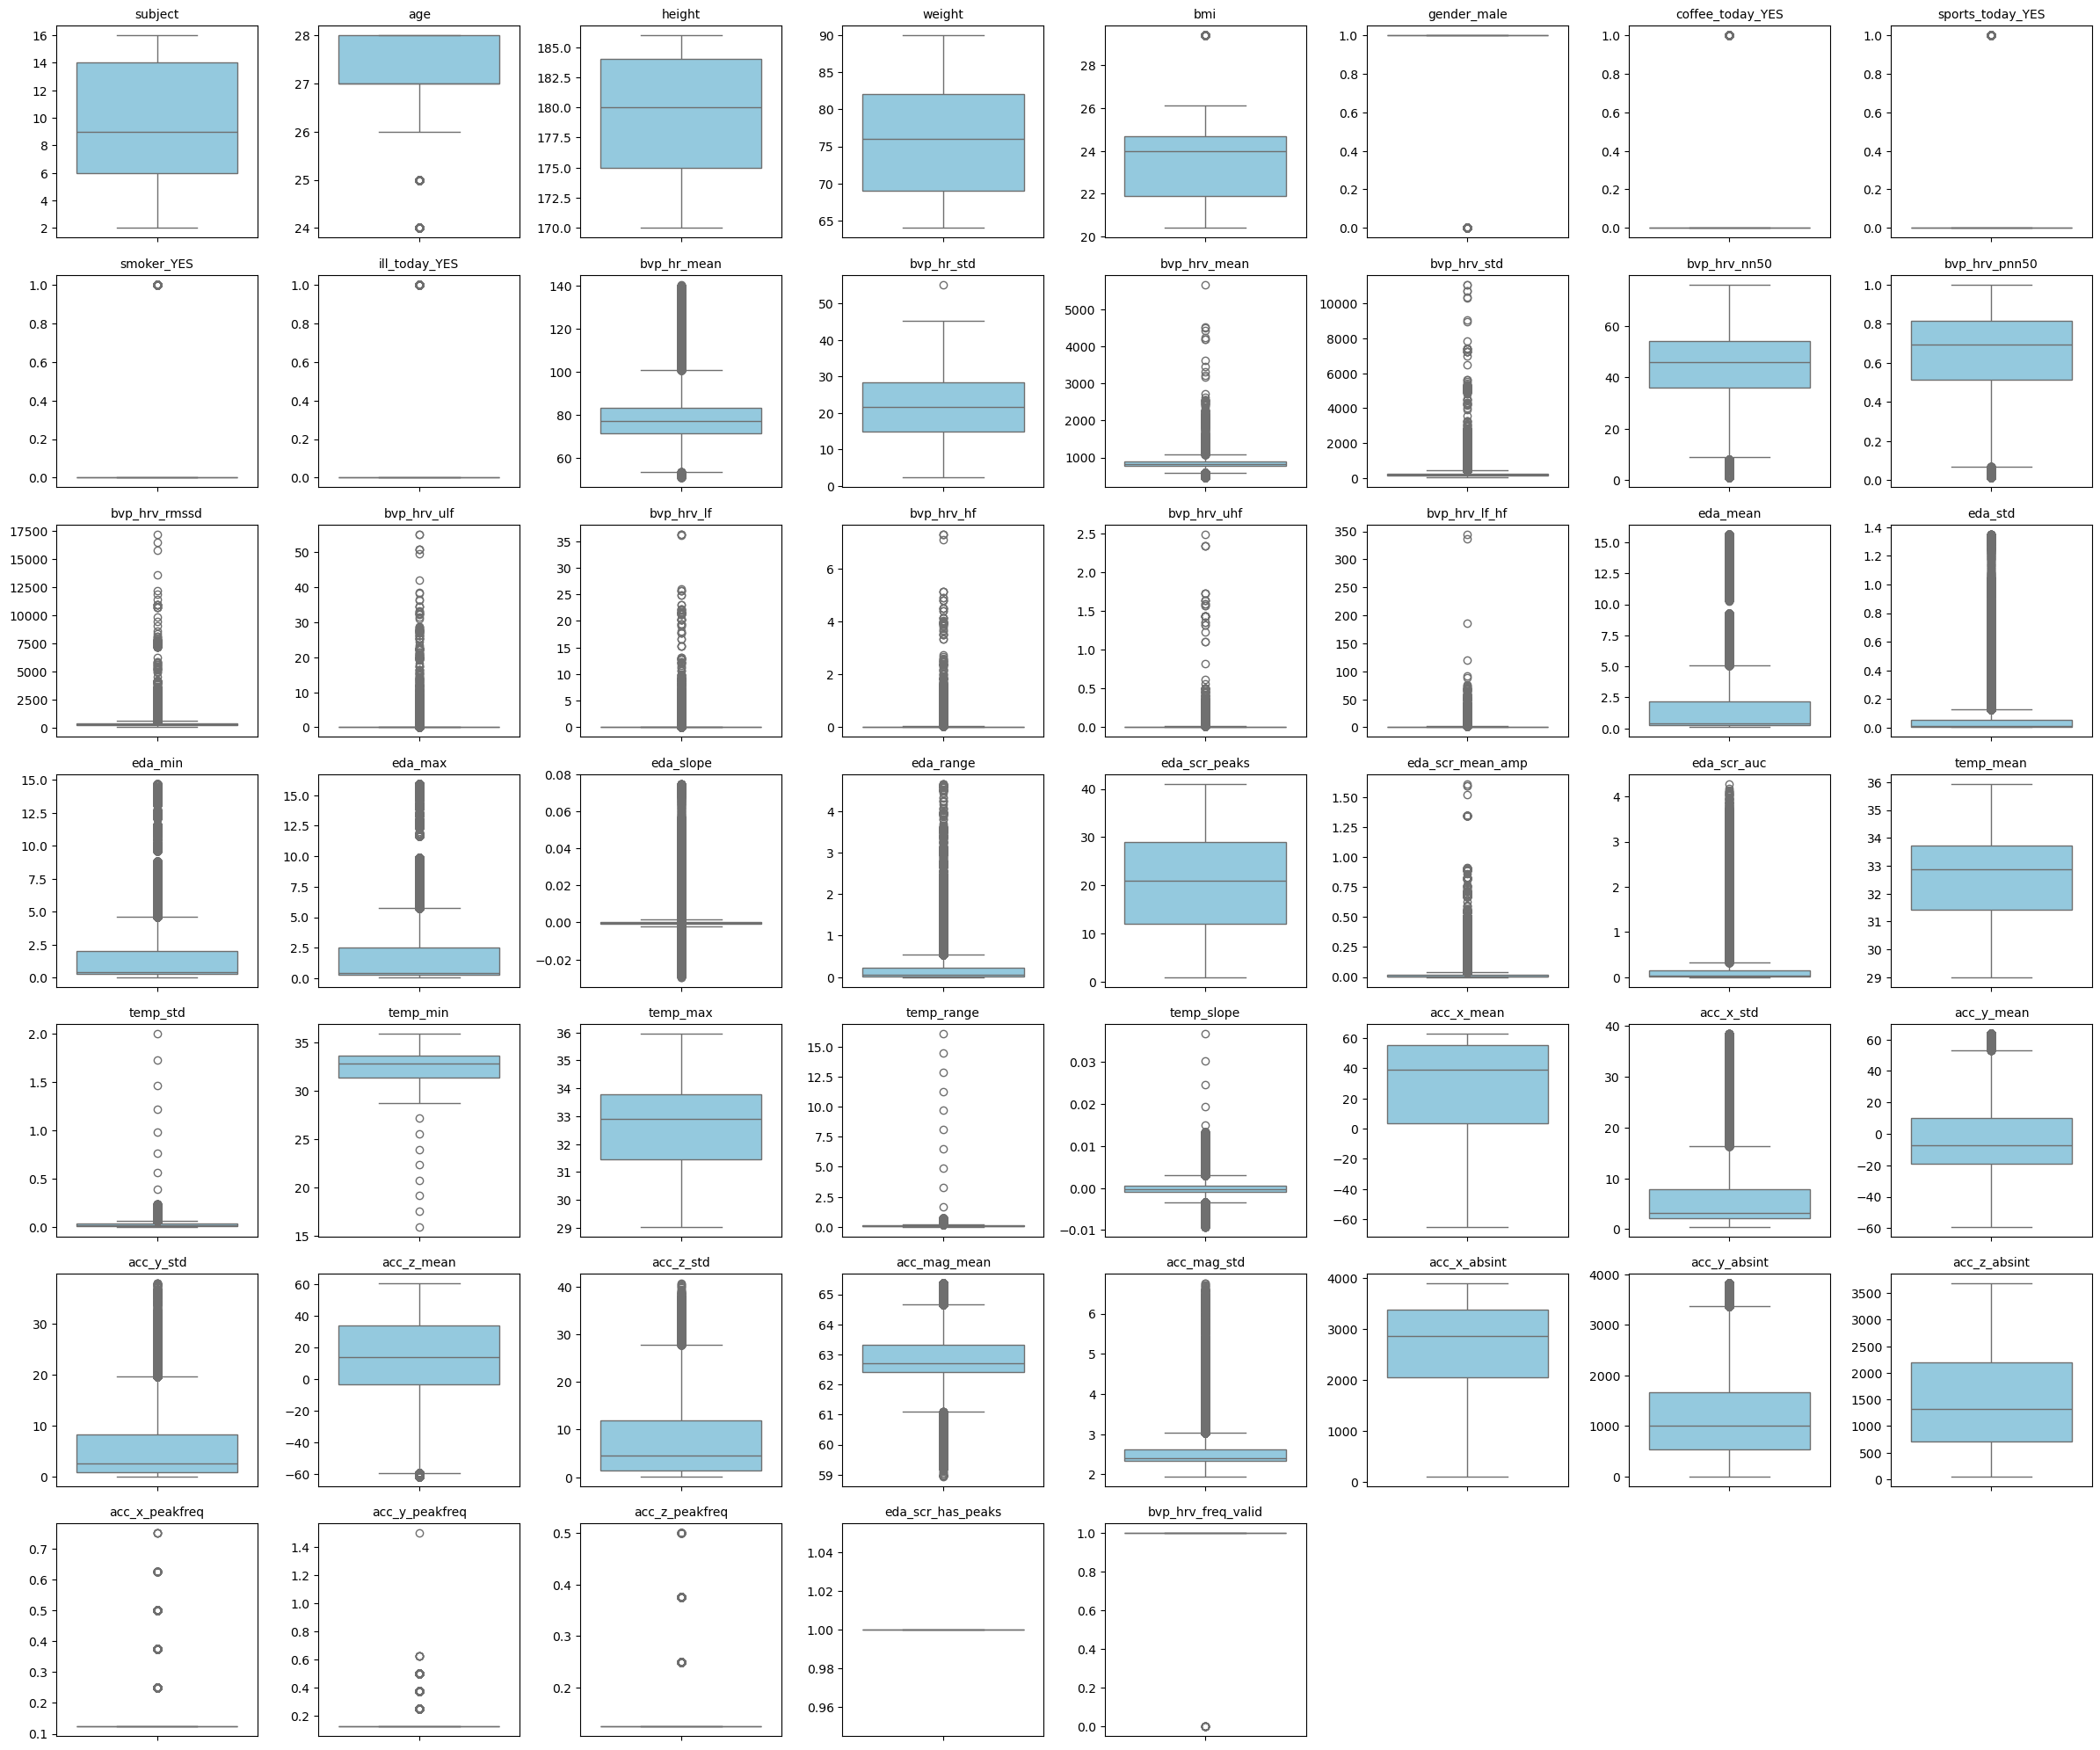

In [10]:
features = list(known_data.columns)


fig, axes = plt.subplots(7, 8, figsize=(24, 20))
axes = axes.flatten()

# One boxplot per feature
for i, feature in enumerate(features):
    sns.boxplot(y=known_data[feature], ax=axes[i], color='skyblue')
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Remove unused subplots if fewer than 56 features
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [11]:
# calculating skewed features
skewness = known_data.skew()
display(skewness) # some are really bad considering ideal is -1 < x < 1

X_train_log = X_train.copy()
X_val_log = X_val.copy()
X_test_log = X_test.copy()

for feature in list(X_train.columns):
    if np.abs(skewness[feature]) > 1:
        X_train_log[feature] = X_train_log[feature].apply(np.log1p)
        X_val_log[feature] = X_val_log[feature].apply(np.log1p)
        X_test_log[feature] = X_test_log[feature].apply(np.log1p)


subject                0.066932
age                   -1.080297
height                -0.095798
weight                 0.133797
bmi                    0.920166
gender_male           -3.007322
coffee_today_YES       1.786779
sports_today_YES       1.787048
smoker_YES             3.017854
ill_today_YES          3.017193
bvp_hr_mean            1.320040
bvp_hr_std            -0.076504
bvp_hrv_mean           2.979981
bvp_hrv_std           11.682008
bvp_hrv_nn50          -0.650267
bvp_hrv_pnn50         -0.834709
bvp_hrv_rmssd         12.270257
bvp_hrv_ulf           29.478457
bvp_hrv_lf            25.864122
bvp_hrv_hf            27.416484
bvp_hrv_uhf           50.378625
bvp_hrv_lf_hf         36.162991
eda_mean               2.512197
eda_std                4.477147
eda_min                2.445218
eda_max                2.453661
eda_slope              3.995522
eda_range              3.541343
eda_scr_peaks         -0.189887
eda_scr_mean_amp       5.812415
eda_scr_auc            3.791007
temp_mea

In [12]:
# scaling data for MLP
# we fit the scaler on both training and validation splits because both count as "known" data
known_data_log = pd.concat([X_train_log, X_val_log])
scaler = StandardScaler()
known_data_scaled = scaler.fit_transform(known_data_log)

X_train_scaled = scaler.transform(X_train_log)
X_val_scaled = scaler.transform(X_val_log)
X_test_scaled = scaler.transform(X_test_log)

In [13]:
X_train_scaled = pd.DataFrame(columns=features, data=X_train_scaled)
X_train_scaled

X_val_scaled = pd.DataFrame(columns=features, data=X_val_scaled)
X_val_scaled.reset_index(drop=True)
X_val_scaled.index = range(len(X_train_scaled), len(X_train_scaled) + len(X_val_scaled))

X_test_scaled = pd.DataFrame(columns=features, data=X_test_scaled)
X_test_scaled = X_test_scaled.reset_index(drop=True)
X_test_scaled.index = range(len(X_train_scaled) + len(X_val_scaled), 
                            len(X_train_scaled) + len(X_val_scaled) + len(X_test_scaled))


### Correlations

We will be performing clustered feature selection, a greedy algorithm which selects the best features to keep in the modelling process whilst also trying to keep the most diverse set.
To get an idea of which features are best to select, we view the correlation matrix of all features in the training and validation sets.

/home/abiddisco/miniforge3/envs/MLDL4H/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/abiddisco/miniforge3/envs/MLDL4H/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


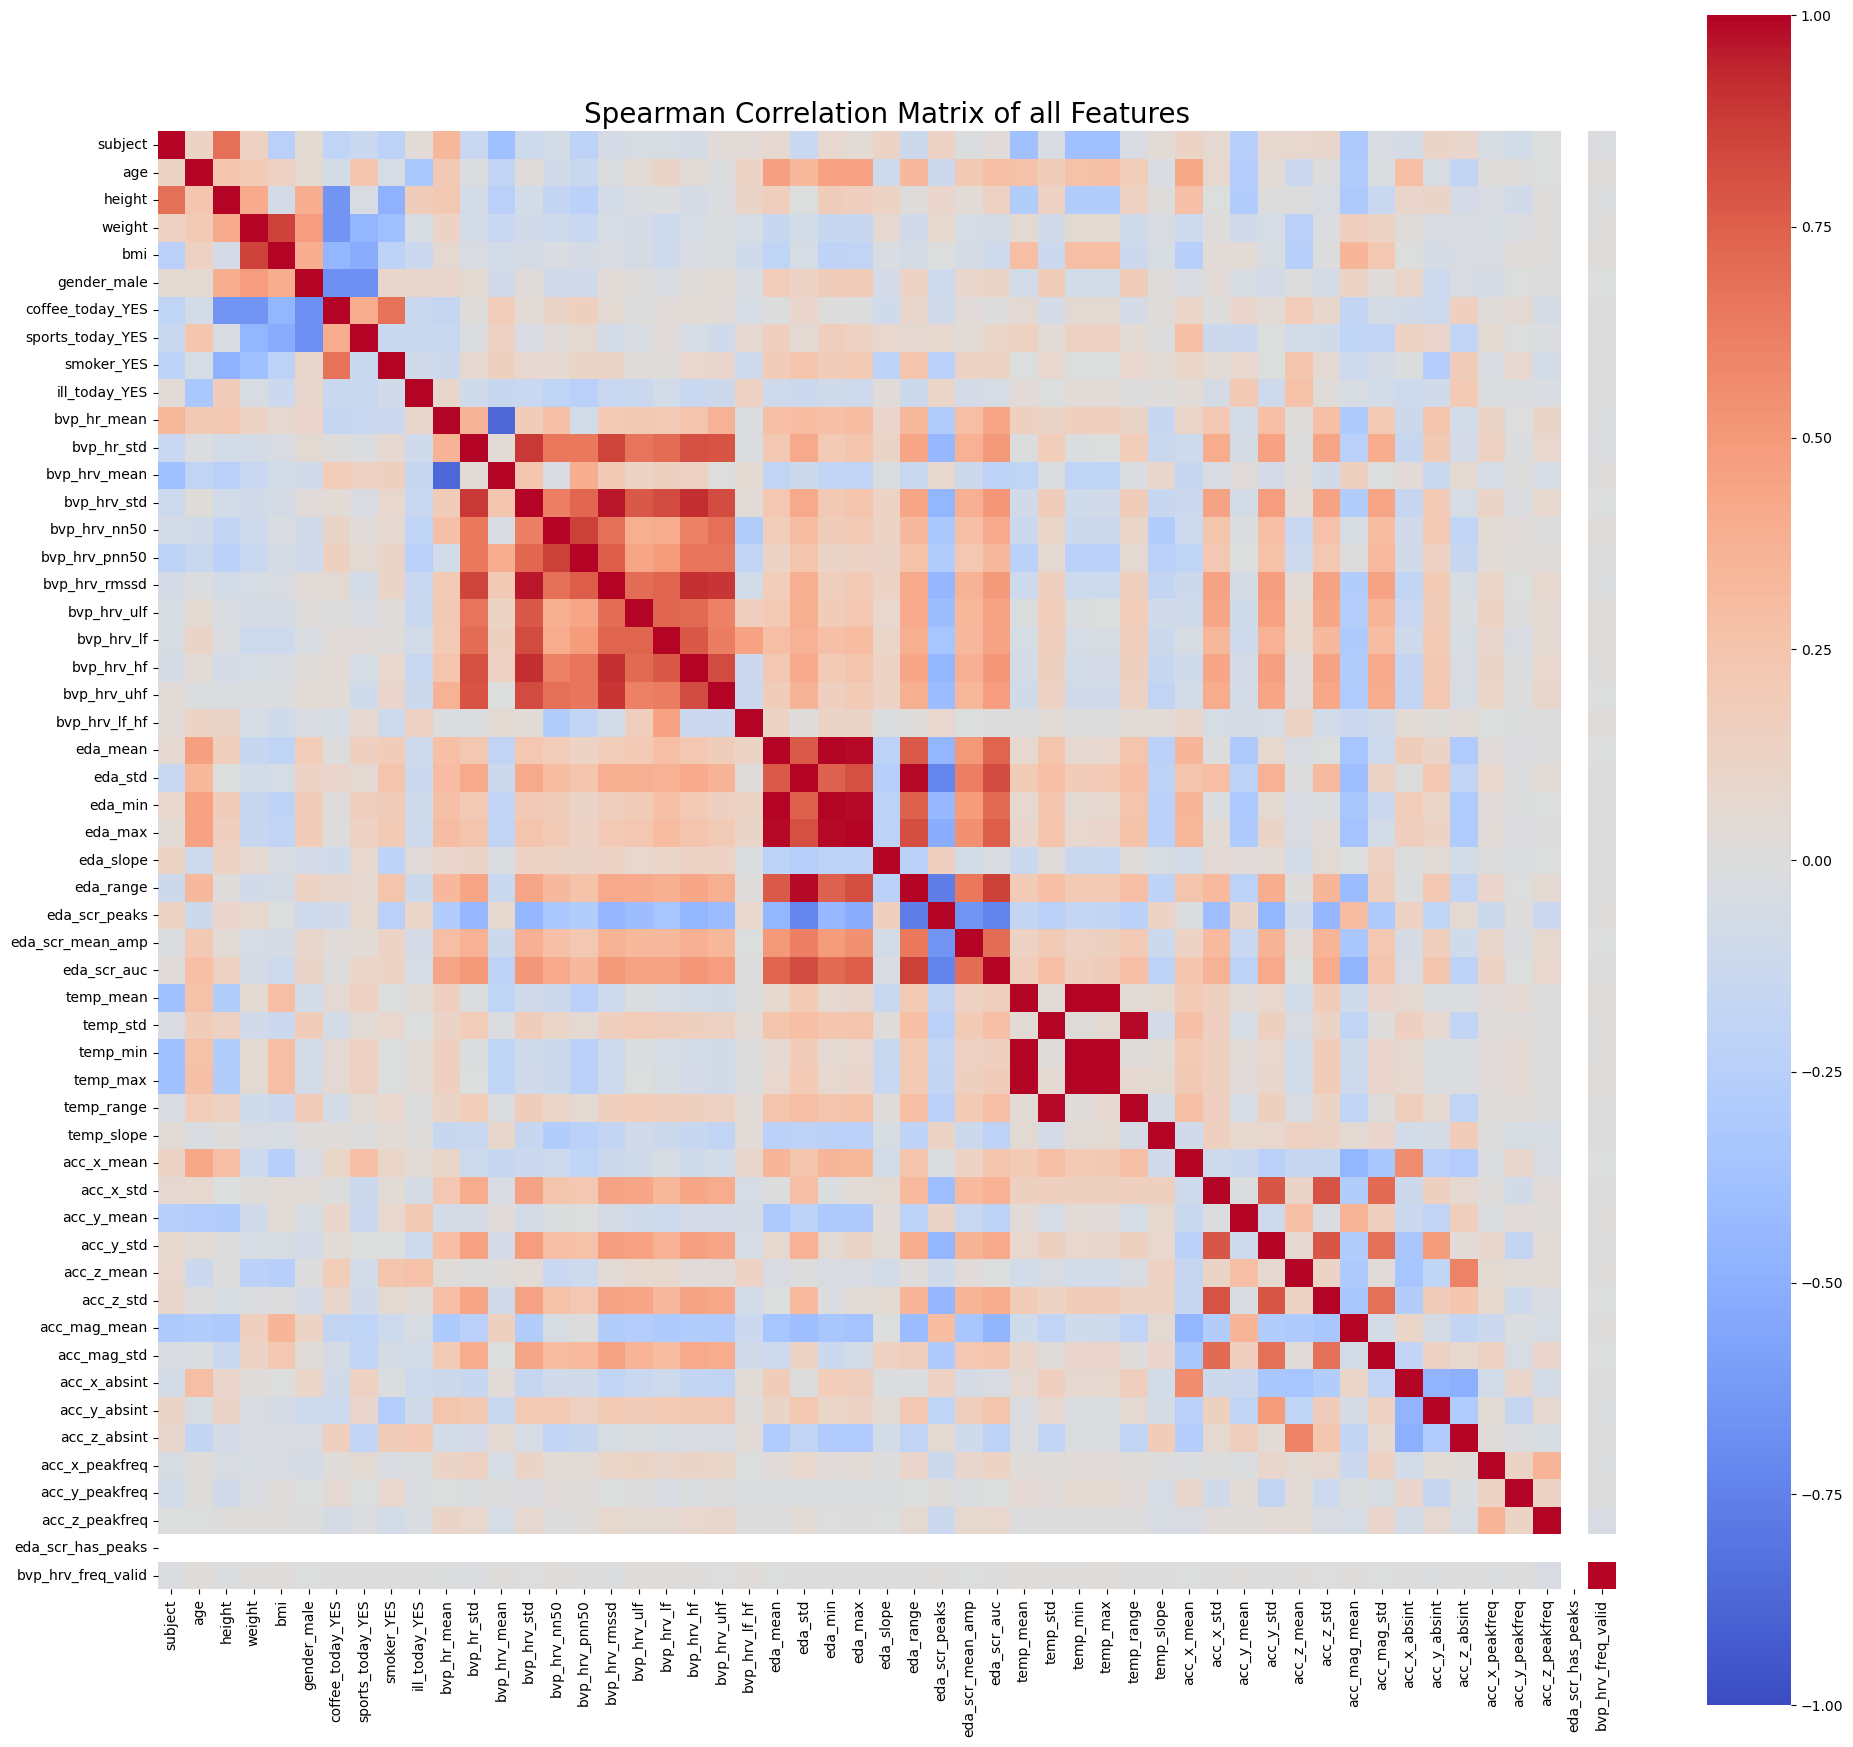

Training set shape: (143669, 53)
Number of descriptors: 53


In [14]:
# function from ML4DD
def spearman_corr_matrix(X: pd.DataFrame) -> pd.DataFrame:
    corr, _ = spearmanr(X)
    return pd.DataFrame(corr, index=X.columns, columns=X.columns)

feature_corr = spearman_corr_matrix(known_data)

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(
    feature_corr,
    annot=False,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, ax=ax,
    xticklabels=features,
    yticklabels=features,
)
ax.set_title('Spearman Correlation Matrix of all Features', fontsize=20)
plt.tight_layout()
plt.show()

print(f"Training set shape: {known_data.shape}")
print(f"Number of descriptors: {len(features)}")

This function used for clustered forwards seelection is taken from the lectures of Machine Learning for Drug Design in which we experimented with different methods for feature selection. 

The best greedy method is, in general, this one, so we are not going to bother with multiple methods when we expect good results from this one.

### Modelling

As mentioned before, we are using 2 ensemble models, Random Forest as a baseline because it is used often, and XGBoost because we expect its complexity will give additional benefits.
To add a third, neural network kind of model, we added a simple custom Multi-Layer Perceptron model, which will at least give us a different kind of model to compare.

In this modelling part we intended to perform feature selection as well, so that we can evaluate what kind of data is most useful in such a healthcare problem without using the temporal data, but a student's laptop kept being able to run this code inconsistently (sometimes yes, then randomly no), so we removed it instead of submitting the code late, which is why some of the following code is unused.


In [15]:
# model definitions
rf_model = RandomForestClassifier(n_estimators=20, random_state=42, n_jobs=-1)
xgb_model = XGBClassifier(n_estimators=20, random_state=42, verbosity=0, n_jobs=-1)

custom_mlp = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(4, activation='softmax')
])

custom_mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/home/abiddisco/miniforge3/envs/MLDL4H/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1778450035.414507 1221850 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778450035.415194 1222172 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778450035.481819 1221850 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you woul

In [16]:
def clustered_forward_selection(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    corr_matrix: pd.DataFrame,
    model,
    corr_threshold: float = 0.6,
    max_features: int = 10,
    cv: int = 5,
    random_state: int = 42
) -> list:
    """
    Clustered forward feature selection.

    Features are first grouped by correlation using a threshold on the
    absolute Spearman correlation matrix. At each round only one candidate
    per cluster is considered (the one not yet selected from that cluster).
    The candidate that maximises CV R² is added to the selected set and its
    cluster is locked — no further candidates are drawn from it until all
    other clusters have contributed a feature.

    Parameters
    ----------
    X_train : pd.DataFrame of shape (n_samples, n_features)
    y_train : pd.Series of shape (n_samples,)
    corr_matrix : pd.DataFrame
        Precomputed Spearman correlation matrix (from spearman_corr_matrix).
    corr_threshold : float
        Features with |correlation| >= corr_threshold are placed in the
        same cluster.
    max_features : int
        Maximum number of features to select.
    cv : int
        Number of cross-validation folds.
    random_state : int

    Returns
    -------
    selected : list of str
        Ordered list of selected feature names.
    scores : list of float
        CV R² score after adding each selected feature.
    cluster_labels : dict
        Mapping from feature name to cluster id.
    """
    features = list(X_train.columns)
    abs_corr = corr_matrix.abs()

    # Step 1: assign each feature to a cluster
    cluster_labels = {}
    cluster_id     = 0
    unassigned     = set(features)

    for feat in features:
        if feat not in unassigned:
            continue
        correlated = set(
            abs_corr.index[abs_corr[feat] >= corr_threshold].tolist()
        ) & unassigned
        for f in correlated:
            cluster_labels[f] = cluster_id
        unassigned -= correlated
        cluster_id += 1

    # Step 2: greedy forward selection with one candidate per cluster
    selected         = []
    scores           = []
    locked_clusters  = set()

    while len(selected) < max_features:
        available_clusters = [
            cid for cid in set(cluster_labels.values())
            if cid not in locked_clusters
        ]
        if not available_clusters:
            break

        # one candidate per available cluster
        candidates = []
        for cid in available_clusters:
            cluster_features = [
                f for f, c in cluster_labels.items()
                if c == cid and f not in selected
            ]
            if not cluster_features:
                continue

            best_cluster_score   = -np.inf
            best_cluster_feature = None
            for f in cluster_features:
                score    = cross_val_score(
                    model, X_train[[f]], y_train,
                    cv=cv, scoring='r2',
                ).mean()
                if score > best_cluster_score:
                    best_cluster_score   = score
                    best_cluster_feature = f
            if best_cluster_feature is not None:
                candidates.append(best_cluster_feature)

        if not candidates:
            break

        # evaluate each candidate in context and pick the best one
        best_score   = -np.inf
        best_feature = None

        for feature in candidates:
            candidate_set = selected + [feature]
            cv_score      = cross_val_score(
                model, X_train[candidate_set], y_train,
                cv=cv, scoring='r2',
            ).mean()
            if cv_score > best_score:
                best_score   = cv_score
                best_feature = feature

        if best_feature is None:
            break

        selected.append(best_feature)
        scores.append(best_score)
        locked_clusters.add(cluster_labels[best_feature])

    return selected, scores, cluster_labels


In [17]:

# print("\nRunning Clustered Forward Selection for Random Forest Model")

# selected_cfs_rf, scores_cfs_rf, cluster_labels_rf = clustered_forward_selection(
#     X_train_log, y_train,
#     corr_matrix=feature_corr,
#     model = rf_model,
#     corr_threshold=0.65,
#     max_features=35,
#     cv=5,
#     random_state=42,
# )
# opt_nr_var_cfs_rf = np.argmax(scores_cfs_rf) + 1
# best_selected_cfs_rf = selected_cfs_rf[:opt_nr_var_cfs_rf]
# print(f"\nCFS optimal: {opt_nr_var_cfs_rf} features (CV R²={scores_cfs_rf[opt_nr_var_cfs_rf-1]:.3f})")
# print(f"Number of clusters found: {len(set(cluster_labels_rf.values()))}")


In [18]:

# print("\nRunning Clustered Forward Selection for XGBoost Model")

# selected_cfs_xgb, scores_cfs_xgb, cluster_labels_xgb = clustered_forward_selection(
#     X_train_log, y_train,
#     corr_matrix=feature_corr,
#     model = xgb_model,
#     corr_threshold=0.65,
#     max_features=35,
#     cv=5,
#     random_state=42,
# )
# opt_nr_var_cfs_xgb = np.argmax(scores_cfs_xgb) + 1
# best_selected_cfs_xgb = selected_cfs_xgb[:opt_nr_var_cfs_xgb]
# print(f"\nCFS optimal: {opt_nr_var_cfs_xgb} features (CV R²={scores_cfs_xgb[opt_nr_var_cfs_xgb-1]:.3f})")
# print(f"Number of clusters found: {len(set(cluster_labels_xgb.values()))}")

In [19]:

# print("\nRunning Clustered Forward Selection for MLP Model")

# selected_cfs_mlp, scores_cfs_mlp, cluster_labels_mlp = clustered_forward_selection(
#     X_train_scaled, y_train,
#     corr_matrix=feature_corr,
#     model = custom_mlp,
#     corr_threshold=0.65,
#     max_features=35,
#     cv=5,
#     random_state=42,
# )
# opt_nr_var_cfs_mlp = np.argmax(scores_cfs_mlp) + 1
# best_selected_cfs_mlp = selected_cfs_mlp[:opt_nr_var_cfs_mlp]
# print(f"\nCFS optimal: {opt_nr_var_cfs_mlp} features (CV R²={scores_cfs_mlp[opt_nr_var_cfs_mlp-1]:.3f})")
# print(f"Number of clusters found: {len(set(cluster_labels_mlp.values()))}")

In [20]:
# # Score curves
# fig, ax = plt.subplots(figsize=(10, 5))

# ax.plot(range(1, len(scores_cfs_rf) + 1), scores_cfs_rf,
#         marker='.', linestyle='--',
#         label='CFS on Random Forest Classifier', color='tab:red')
# ax.axvline(opt_nr_var_cfs_rf, color='tab:red', linestyle='--', alpha=0.5,
#            label=f'CFS optimal: {opt_nr_var_cfs_rf} features (R²={scores_cfs_rf[opt_nr_var_cfs_rf-1]:.3f})')

# ax.plot(range(1, len(scores_cfs_xgb) + 1), scores_cfs_xgb,
#         marker='.', linestyle='--',
#         label='CFS XGBoost Classifier', color='tab:green')
# ax.axvline(opt_nr_var_cfs_xgb, color='tab:green', linestyle='--', alpha=0.5,
#            label=f'CFS optimal: {opt_nr_var_cfs_xgb} features (R²={scores_cfs_xgb[opt_nr_var_cfs_xgb-1]:.3f})')

# ax.plot(range(1, len(scores_cfs_mlp) + 1), scores_cfs_mlp,
#         marker='.', linestyle='--',
#         label='CFS XGBoost Classifier', color='tab:blue')
# ax.axvline(opt_nr_var_cfs_xgb, color='tab:blue', linestyle='--', alpha=0.5,
#            label=f'CFS optimal: {opt_nr_var_cfs_mlp} features (R²={scores_cfs_mlp[opt_nr_var_cfs_mlp-1]:.3f})')

# ax.set_xlabel('Number of Selected Features')
# ax.set_ylabel('CV R²')
# ax.set_title('Feature Selection Score Curves for 2 models')
# ax.legend()
# plt.tight_layout()
# plt.show()

# # Print selected features
# print(f"\n{opt_nr_var_cfs_xgb} optimal features for Random Forest:")
# print(best_selected_cfs_rf)
# print(f"\n{opt_nr_var_cfs_xgb} optimal features for XGBoost:")
# print(best_selected_cfs_xgb)
# print(f"\n{opt_nr_var_cfs_mlp} optimal features for MLP:")
# print(best_selected_cfs_mlp)


In [21]:
# all_selected_features = [x for x in itertools.chain(best_selected_cfs_rf, 
#                                                     best_selected_cfs_xgb, 
#                                                     best_selected_cfs_mlp)]
# unique_features = list(set(all_selected_features))
# times_used = {}
# for feature in unique_features:
#     times_used[feature] = 0
#     for item in all_selected_features:
#         if feature == item:
#             times_used[feature] += 1

# times_used = sorted(times_used)

# plt.bar(times_used)
# plt.xlabel("Number of models using this feature")
# plt.ylabel("Feature name")
# plt.title("Best selected features and the number of models using them")
# plt.show()

### Model training

Now we move on to actually training and tuning the models. 
We use the validation set to perform automatic hyperparameter tuning, and automatically use the optimal number of features calculated using CFS for the training. 

For each model we will determine the training, validation and testing sets in a custom way, because we performed different normalisation steps (and intended to add different feature selections for each different type of model as well). 

We start with the Random Forest Classifier, to be used as the generic baseline model.


In [22]:
X_train_rf = X_train_log # [best_selected_cfs_rf]
X_val_rf = X_val_log # [best_selected_cfs_rf]
X_test_rf = X_test_log # [best_selected_cfs_rf]

# Hyperparameter grid
param_grid_rf = {'n_estimators': [20, 50, 70, 100],
                 'max_depth': [None, 5, 10],
                 'min_samples_leaf': [1, 2, 4]}

best_score_rf = 0
best_params_rf = None
best_model_rf = None

for params in itertools.product(param_grid_rf['n_estimators'],
                                param_grid_rf['max_depth'],
                                param_grid_rf['min_samples_leaf']):

    model = RandomForestClassifier(
        n_estimators=params[0],
        max_depth=params[1],
        min_samples_leaf=params[2],
        random_state=42,
        n_jobs=-1)

    model.fit(X_train_rf, y_train)
    preds = model.predict(X_val_rf)

    score = f1_score(y_val, preds, average='macro')
    print(params, score)

    # Save best
    if score > best_score_rf:
        best_score_rf = score
        best_params_rf = params
        best_model_rf = model

print("\nBest RF Params:")
print(best_params_rf)

print("Best Validation F1:")
print(best_score_rf)

(20, None, 1) 0.47825483323851825
(20, None, 2) 0.49205906090889345
(20, None, 4) 0.5017202151175939
(20, 5, 1) 0.4789063696466505
(20, 5, 2) 0.48310007484081535
(20, 5, 4) 0.4853313789751291
(20, 10, 1) 0.4273419651715876
(20, 10, 2) 0.4285095759733469
(20, 10, 4) 0.4481856481073704
(50, None, 1) 0.45860252565717347
(50, None, 2) 0.4609248222641743
(50, None, 4) 0.4694262629430629
(50, 5, 1) 0.48798936671534454
(50, 5, 2) 0.4868900164607376
(50, 5, 4) 0.48813877822864604
(50, 10, 1) 0.44573232518135314
(50, 10, 2) 0.4477549397565076
(50, 10, 4) 0.4487085013345846
(70, None, 1) 0.45521230578472
(70, None, 2) 0.44913702602816064
(70, None, 4) 0.4968496594294658
(70, 5, 1) 0.4890920542861111
(70, 5, 2) 0.48708942019716717
(70, 5, 4) 0.4882224954137864
(70, 10, 1) 0.4444254681742774
(70, 10, 2) 0.45101781069115343
(70, 10, 4) 0.45299338422841356
(100, None, 1) 0.46375253611547007
(100, None, 2) 0.46004618461827396
(100, None, 4) 0.46934597370319203
(100, 5, 1) 0.4906440576253406
(100, 5, 

In [23]:
# predictions
rf_preds = best_model_rf.predict(X_test_rf)


Next, we train the complex model, XGBoost:

In [24]:
X_train_xgb = X_train_log # [best_selected_cfs_xgb]
X_val_xgb = X_val_log # [best_selected_cfs_xgb]
X_test_xgb = X_test_log # [best_selected_cfs_xgb]

param_grid_xgb = {'learning_rate': [0.01, 0.05, 0.1],
                  'max_depth': [3, 5, 7],
                  'n_estimators': [100, 300]}

best_score_xgb = 0
best_params_xgb = None
best_model_xgb = None

for params in itertools.product(param_grid_xgb['learning_rate'],
                                param_grid_xgb['max_depth'],
                                param_grid_xgb['n_estimators']):

    model = XGBClassifier(
        learning_rate=params[0],
        max_depth=params[1],
        n_estimators=params[2],
        random_state=42,
        verbosity=0,
        n_jobs=-1
    )

    model.fit(
        X_train_xgb,
        y_train,
        eval_set=[(X_val_xgb, y_val)],
        verbose=False
    )

    preds = model.predict(X_val)
    score = f1_score(y_val, preds, average='macro')
    print(params, score)

    if score > best_score_xgb:
        best_score_xgb = score
        best_params_xgb = params
        best_model_xgb = model

print("\nBest XGB Params:")
print(best_params_xgb)

print("Best Validation F1:")
print(best_score_xgb)

(0.01, 3, 100) 0.27168924601968375
(0.01, 3, 300) 0.3535099350946509
(0.01, 5, 100) 0.2768213087107508
(0.01, 5, 300) 0.28822042772862483
(0.01, 7, 100) 0.34372910733366424
(0.01, 7, 300) 0.3412262459720208
(0.05, 3, 100) 0.35866275460847363
(0.05, 3, 300) 0.3374627889162049
(0.05, 5, 100) 0.36711628902873356
(0.05, 5, 300) 0.36886249999578474
(0.05, 7, 100) 0.3107594443609305
(0.05, 7, 300) 0.33337808946783654
(0.1, 3, 100) 0.3431836897579677
(0.1, 3, 300) 0.3522183163093343
(0.1, 5, 100) 0.34441308705088297
(0.1, 5, 300) 0.352315708208935
(0.1, 7, 100) 0.35217473830758395
(0.1, 7, 300) 0.3392765279024297

Best XGB Params:
(0.05, 5, 300)
Best Validation F1:
0.36886249999578474


In [25]:
# predictions
xgb_preds = best_model_xgb.predict(X_test_xgb)



And lastly, the custom MLP model:

In [26]:
def build_mlp(hidden1, hidden2, dropout1, dropout2):

    model = Sequential([Dense(hidden1, activation='relu', input_shape=(X_train_scaled.shape[1],)),
                        Dropout(dropout1),
                        Dense(hidden2, activation='relu'),
                        Dropout(dropout2),
                        Dense(4, activation='softmax')])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [28]:
X_train_mlp = X_train_scaled # [best_selected_cfs_mlp]
X_val_mlp = X_val_scaled # [best_selected_cfs_mlp]
X_test_mlp = X_test_scaled # [best_selected_cfs_mlp]

param_grid_mlp = {'hidden1': [32, 64],
                  'hidden2': [16, 32],
                  'dropout1': [0.2, 0.3],
                  'dropout2': [0.2, 0.3]}

best_score_mlp = 0
best_params_mlp = None
best_model_mlp = None
histories_mlp = []

for params in itertools.product(param_grid_mlp['hidden1'],
                                param_grid_mlp['hidden2'],
                                param_grid_mlp['dropout1'],
                                param_grid_mlp['dropout2']):

    model = build_mlp(*params)

    early_stop = EarlyStopping(monitor='val_loss',
                               patience=10,
                               restore_best_weights=True)

    history = model.fit(X_train_mlp,
              y_train,
              validation_data=(X_val_mlp, y_val),
              epochs=100,
              batch_size=32,
              callbacks=[early_stop],
              verbose=0)
    histories_mlp.append(history)

    preds = model.predict(X_val_mlp)
    preds = preds.argmax(axis=1)

    score = f1_score(y_val, preds, average='macro')

    print(params, score)

    if score > best_score_mlp:
        best_score_mlp = score
        best_params_mlp = params
        best_model_mlp = model

print("\nBest MLP Params:")
print(best_params_mlp)

print("Best Validation F1:")
print(best_score_mlp)

/home/abiddisco/miniforge3/envs/MLDL4H/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


745/745 ━━━━━━━━━━━━━━━━━━━━ 0s 429us/step
(32, 16, 0.2, 0.2) 0.38647523383711646


/home/abiddisco/miniforge3/envs/MLDL4H/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


745/745 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step
(32, 16, 0.2, 0.3) 0.41494400050071845


/home/abiddisco/miniforge3/envs/MLDL4H/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

745/745 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step
(64, 32, 0.2, 0.3) 0.40611310622880137


/home/abiddisco/miniforge3/envs/MLDL4H/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


745/745 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step
(64, 32, 0.3, 0.2) 0.3956293520626575


/home/abiddisco/miniforge3/envs/MLDL4H/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


745/745 ━━━━━━━━━━━━━━━━━━━━ 0s 532us/step
(64, 32, 0.3, 0.3) 0.4081577980581853

Best MLP Params:
(32, 16, 0.3, 0.3)
Best Validation F1:
0.4802385636374038


In [29]:
# predictions
mlp_preds = best_model_mlp.predict(X_test_mlp)
mlp_preds = mlp_preds.argmax(axis=1)


1130/1130 ━━━━━━━━━━━━━━━━━━━━ 1s 521us/step


### Model Comparison and Evaluation 

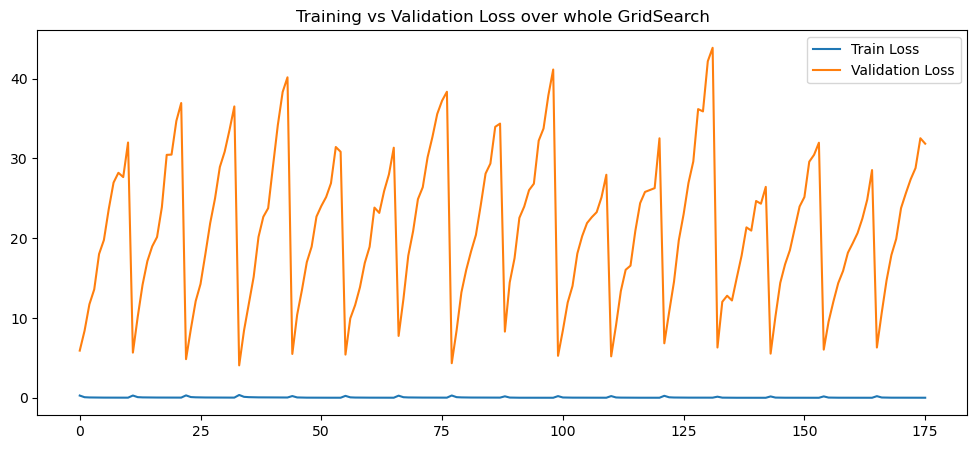

In [30]:
all_losses = []
for history in histories_mlp:
    all_losses.extend(history.history["loss"])
all_val_losses = []
for history in histories_mlp:
    all_val_losses.extend(history.history["val_loss"])

plt.figure(figsize=(12,5))
plt.plot(all_losses, label='Train Loss')
plt.plot(all_val_losses, label='Validation Loss')
plt.legend()
plt.title('Training vs Validation Loss over whole GridSearch')

plt.show()

In [31]:
results = pd.DataFrame({
    'Model': ['RandomForest', 'XGBoost', 'MLP'],
    'Accuracy': [
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds),
        accuracy_score(y_test, mlp_preds)
    ],
    'F1_macro': [
        f1_score(y_test, rf_preds, average='macro'),
        f1_score(y_test, xgb_preds, average='macro'),
        f1_score(y_test, mlp_preds, average='macro')
    ]
})

print(results)

          Model  Accuracy  F1_macro
0  RandomForest  0.656025  0.539297
1       XGBoost  0.555715  0.489642
2           MLP  0.564374  0.448485


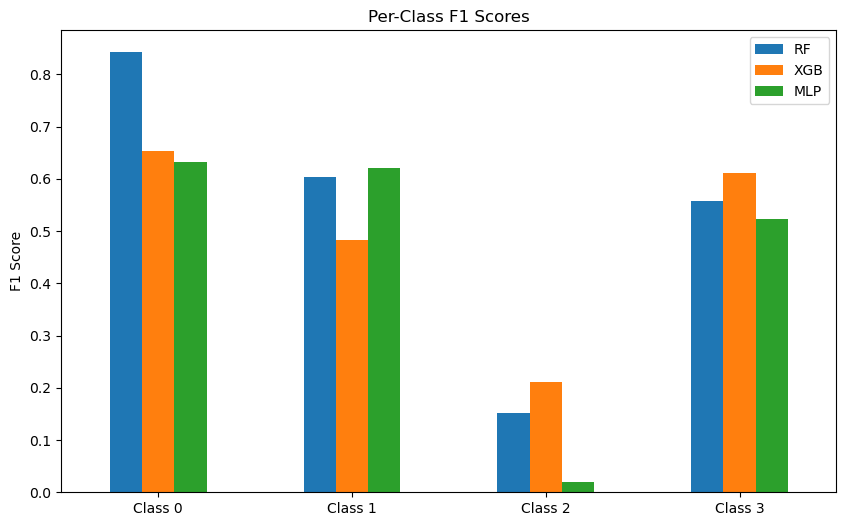

In [32]:

models = {'RF': rf_preds,
          'XGB': xgb_preds,
          'MLP': mlp_preds}

f1_scores = {}

for name, preds in models.items():
    _, _, f1, _ = precision_recall_fscore_support(y_test, preds)
    f1_scores[name] = f1

f1_df = pd.DataFrame(f1_scores)
f1_df.index = [f'Class {i}' for i in range(4)]
f1_df.plot(kind='bar', figsize=(10,6))

plt.ylabel('F1 Score')
plt.title('Per-Class F1 Scores')
plt.xticks(rotation=0)

plt.show()

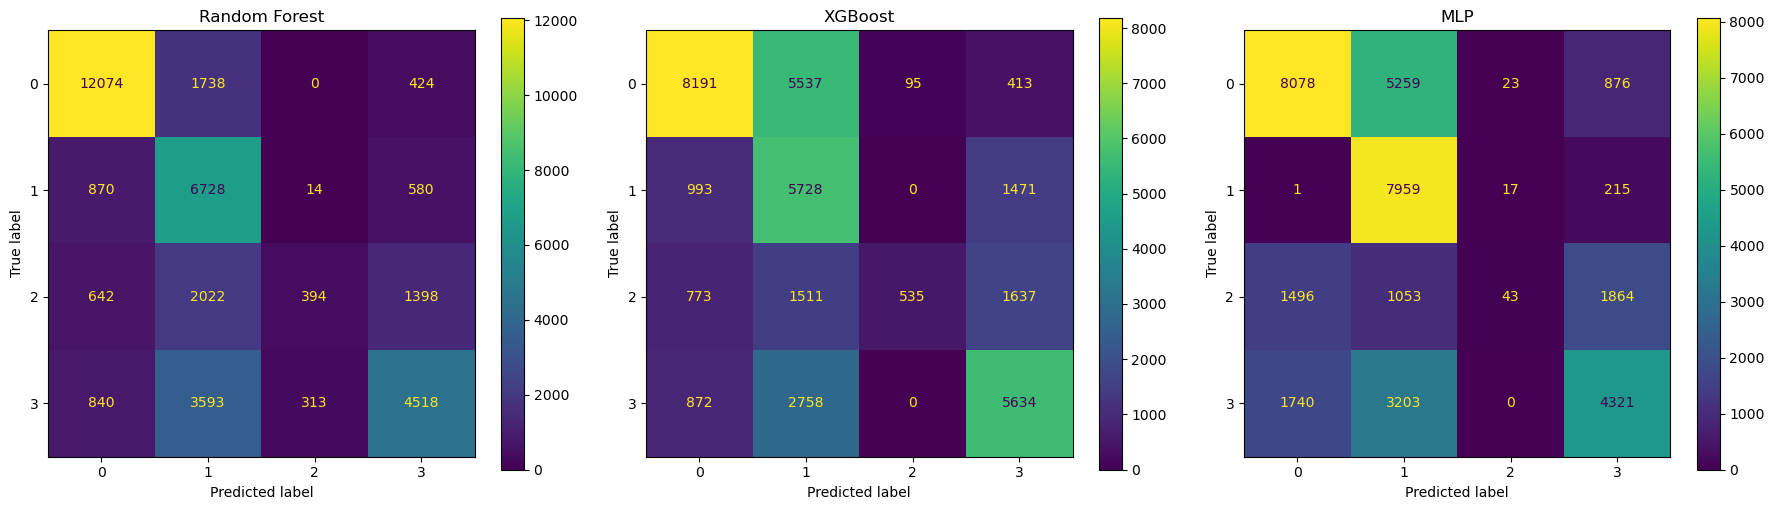

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, ax=axes[0])
axes[0].set_title("Random Forest")

ConfusionMatrixDisplay.from_predictions(y_test, xgb_preds, ax=axes[1])
axes[1].set_title("XGBoost")

ConfusionMatrixDisplay.from_predictions(y_test, mlp_preds, ax=axes[2])
axes[2].set_title("MLP")

plt.tight_layout()
plt.show()

The F1 barplot, comparison of accuracies and even the confusion matrices show that the models are able to predict well in reference to the most common class, the baseline, but often make mistakes in relation to the stress signal, with the worst performance going to the "excitement" class which is underestimated by the models. This shows that there are significant similarities in the less frequent classes, which cannot be easily told apart without using temporal daata (window_index that we originally removed). 

### Model Explanations

We perform some minimal model explanation using SHAP, simply to obtain some information about the models trained.
The following SHAP graphs describe simply which are the most important features, which is necessary as we weren't able to complete the initially wanted cluster feature selection (CFS).

This does beg the question about whether the personal data used in this model is polluting the dataset, as the most important features are not signal features and that is unexpected.

This does show that we were able to use the metadata to inform more decisions, and we presume the features interacted with each other as someone with a certain age will have different physiological responses to someone with a different age, but in conclusion, if redoing the project in the future, we would move to avoiding personal data for fear of overfitting or some form of contamination.

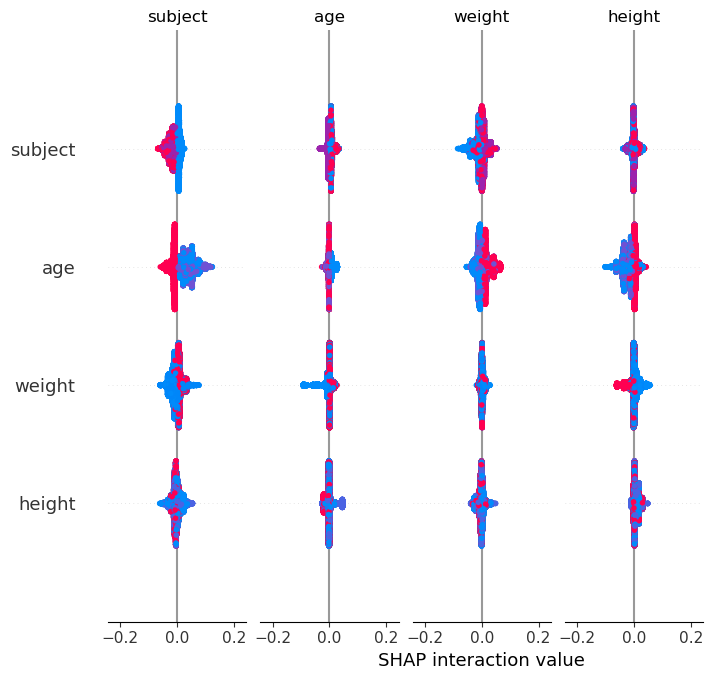

In [34]:
# trees
explainer = shap.TreeExplainer(best_model_rf)

rf_shap_values = explainer.shap_values(X_test_rf)

shap.summary_plot(
    rf_shap_values,
    X_test,
    feature_names=X_train.columns
)


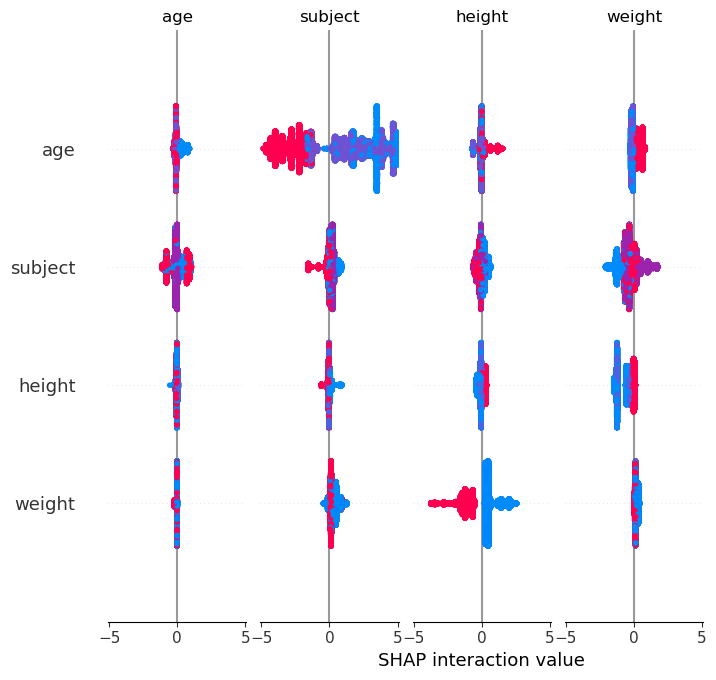

In [35]:
explainer = shap.TreeExplainer(best_model_xgb)
xgb_shap_values = explainer.shap_values(X_test_xgb)

shap.summary_plot(
    xgb_shap_values,
    X_test,
    feature_names=X_train.columns
)


/home/abiddisco/miniforge3/envs/MLDL4H/lib/python3.13/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_192
Received: inputs=['Tensor(shape=(36148, 53))']
  warnings.warn(msg)
/home/abiddisco/miniforge3/envs/MLDL4H/lib/python3.13/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_192
Received: inputs=['Tensor(shape=(50, 53))']
  warnings.warn(msg)
/tmp/ipykernel_1221850/1413387146.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(mlp_shap_values, X_explain, feature_names=X_train.columns)
/home/abiddisco/miniforge3/envs/MLDL4H/lib/python3.13/site-packages/shap/plots/_beeswarm.py:723: FutureWarn

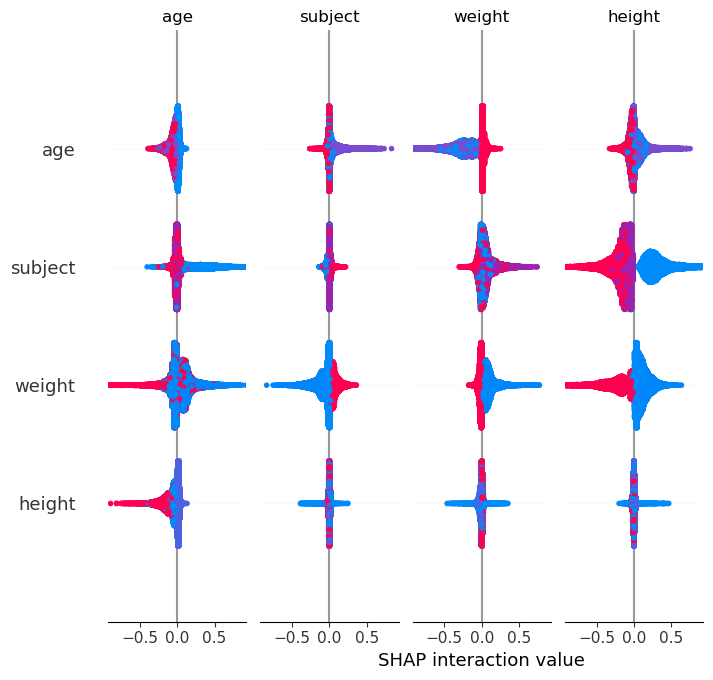

In [38]:
# MLP

# Only works if you convert to numpy arrays
X_background = X_train_mlp.to_numpy() # [:100]
X_explain = X_test_mlp.to_numpy() # .iloc[:100]

explainer = shap.GradientExplainer(best_model_mlp, X_background)

mlp_shap_values = explainer.shap_values(X_explain)

shap.summary_plot(mlp_shap_values, X_explain, feature_names=X_train.columns)

In [ ]:
# Comparing top features
# rf_importance = np.abs(rf_shap_values).mean(axis=0)
# xgb_importance = np.abs(xgb_shap_values).mean(axis=0)
# mlp_importance = np.abs(mlp_shap_values[0]).mean(axis=0)

rf_importance = np.abs(rf_shap_values).mean(axis=(0,2))
xgb_importance = np.abs(xgb_shap_values).mean(axis=(0,2))
mlp_importance = np.abs(mlp_shap_values).mean(axis=(0,2))

print("RF:", np.array(rf_shap_values).shape)
print("XGB:", np.array(xgb_shap_values).shape)
print("MLP:", np.array(mlp_shap_values).shape)

importance_df = pd.DataFrame({'Feature': X_train.columns,
                              'RF': rf_importance,
                              'XGB': xgb_importance,
                              'MLP': mlp_importance})

importance_df = importance_df.set_index('Feature')

print(importance_df.sort_values('XGB', ascending=False).head(10))

RF: (36148, 53, 4)
XGB: (36148, 53, 4)
MLP: (36148, 53, 4)
                    RF       XGB       MLP
Feature                                   
temp_max      0.021415  0.840397  0.019882
eda_mean      0.027018  0.777897  0.019803
acc_y_absint  0.016398  0.479654  0.041409
subject       0.010735  0.460178  0.025757
acc_z_mean    0.014879  0.392248  0.038461
acc_x_mean    0.010820  0.382355  0.025628
eda_scr_auc   0.021884  0.347027  0.018833
bvp_hr_mean   0.017927  0.328229  0.037232
temp_min      0.022412  0.295067  0.028050
eda_min       0.027860  0.280703  0.018553


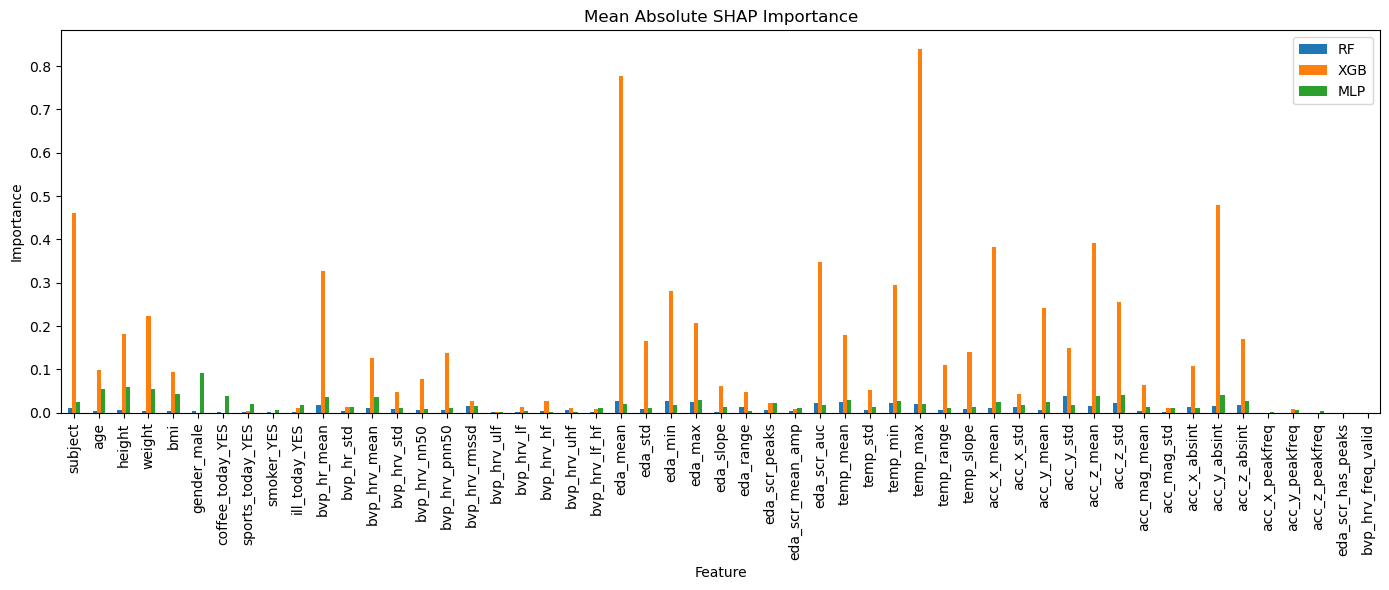

In [51]:
importance_df.plot(kind='bar', figsize=(14,6))
# plt.hist(features, rf_importance)
plt.title('Mean Absolute SHAP Importance')
plt.ylabel('Importance')

plt.tight_layout()
plt.show()